# Model Explainability and Monitoring

## Run StratifiedKFold CV (5 folds) on your best pipeline. Report mean and std of AUROC. Is performance stable across folds?

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import shap
import os
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

In [2]:
# load best pipeline
best_model_path = Path(f"{os.getcwd()}/../models/best_model.pkl")
with open(best_model_path, mode='rb') as f:
    best_model = joblib.load(f)

df_path = Path(f"{os.getcwd()}/../data/preprocessed_train.csv")
df = pd.read_csv(df_path)

df = df.drop(columns=['Unnamed: 0', 'SK_ID_CURR'])

In [3]:
best_model

,steps,"[('preprocesser', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X, y = df.drop(columns=['TARGET']), df['TARGET']
scores = cross_val_score(best_model, X, y, cv=cv, scoring='roc_auc')
display(np.mean(scores))
display(np.std(scores))
display(scores)

0.751060482341186

0.004566917457853851

array([0.74650205, 0.75681222, 0.75200196, 0.754854  , 0.74513218])

The results across the folds are consistent and stable performance wise. AUROC is across 0.7 and with little variability across folds

## 3. Generate SHAP values for 1,000 random test samples (full test set may be slow). Create: (a) SHAP summary beeswarm plot, (b) SHAP bar plot of mean |SHAP| by feature.

In [5]:
from shap import Explainer
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_sample = X_test.sample(n=1000, random_state=42)

In [6]:
X_sample

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,"AGE_BUCKET_(20, 30]","AGE_BUCKET_(30, 40]","AGE_BUCKET_(40, 50]","AGE_BUCKET_(50, 60]","AGE_BUCKET_(60, 70]","AGE_BUCKET_(70, 100]"
14343,0,270000.0,1031053.5,34204.5,783000.0,4,0.006233,-17143,-476.0,-2549.0,...,0,1,0,0,0,0,1,0,0,0
94529,1,157500.0,450000.0,42075.0,450000.0,4,0.010147,-11881,-311.0,-10275.0,...,0,0,0,0,0,1,0,0,0,0
26833,0,112500.0,195543.0,13198.5,148500.0,2,0.025164,-15038,-710.0,-2986.0,...,0,0,0,0,0,0,1,0,0,0
101924,0,99000.0,229500.0,14796.0,229500.0,2,0.028663,-21600,-1648.0,-1638.0,...,0,0,1,0,0,0,0,1,0,0
281182,0,405000.0,450000.0,30442.5,450000.0,2,0.028663,-10648,-808.0,-4107.0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71497,0,126000.0,450000.0,12375.0,450000.0,4,0.030755,-10994,-1277.0,-4126.0,...,0,0,0,0,0,1,0,0,0,0
131001,0,76500.0,225000.0,11250.0,225000.0,2,0.006008,-11585,-348.0,-5975.0,...,0,0,0,0,0,1,0,0,0,0
263159,1,202500.0,1078200.0,31653.0,900000.0,3,0.006207,-10677,-3737.0,-1069.0,...,0,0,1,0,1,0,0,0,0,0
122236,0,135000.0,495000.0,19179.0,495000.0,2,0.026392,-9652,-863.0,-4397.0,...,0,0,0,0,1,0,0,0,0,0


In [7]:
model = best_model.named_steps['model']
preprocessor = best_model.named_steps['preprocesser']

# transform the sample according to the pipeline transformer
X_sample_normalized = preprocessor.transform(X_sample)

# convert transformed array into Dataframe and rename the columns so SHAP plots have feature names and not just numbers
X_sample_normalized = pd.DataFrame(X_sample_normalized)
X_sample_normalized.columns = X_sample.columns

In [8]:
X_sample_normalized

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,"AGE_BUCKET_(20, 30]","AGE_BUCKET_(30, 40]","AGE_BUCKET_(40, 50]","AGE_BUCKET_(50, 60]","AGE_BUCKET_(60, 70]","AGE_BUCKET_(70, 100]"
0,-0.577538,0.426792,1.073387,0.489602,0.662582,1.704312,-1.058119,-0.253439,0.831202,0.691798,...,-0.235673,2.253525,-0.461015,-0.45078,-0.414144,-0.604552,1.737124,-0.533146,-0.361715,0.0
1,0.807273,-0.047646,-0.370260,1.032641,-0.239153,1.704312,-0.775136,0.952340,0.908443,-1.501294,...,-0.235673,-0.443749,-0.461015,-0.45078,-0.414144,1.654116,-0.575664,-0.533146,-0.361715,0.0
2,-0.577538,-0.237421,-1.002467,-0.959744,-1.055588,-0.582598,0.310593,0.228918,0.721662,0.567751,...,-0.235673,-0.443749,-0.461015,-0.45078,-0.414144,-0.604552,1.737124,-0.533146,-0.361715,0.0
3,-0.577538,-0.294354,-0.918100,-0.849522,-0.836247,-0.582598,0.563570,-1.274754,0.282562,0.950393,...,-0.235673,-0.443749,2.169126,-0.45078,-0.414144,-0.604552,-0.575664,1.875660,-0.361715,0.0
4,-0.577538,0.996117,-0.370260,0.230036,-0.239153,-0.582598,0.563570,1.234880,0.675785,0.249546,...,-0.235673,-0.443749,-0.461015,-0.45078,2.414620,-0.604552,-0.575664,-0.533146,-0.361715,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.577538,-0.180488,-0.370260,-1.016563,-0.239153,1.704312,0.714822,1.155595,0.456236,0.244153,...,-0.235673,-0.443749,-0.461015,-0.45078,-0.414144,1.654116,-0.575664,-0.533146,-0.361715,0.0
996,-0.577538,-0.389241,-0.929280,-1.094184,-0.848433,-0.582598,-1.074386,1.020168,0.891122,-0.280702,...,-0.235673,-0.443749,-0.461015,-0.45078,-0.414144,1.654116,-0.575664,-0.533146,-0.361715,0.0
997,0.807273,0.142129,1.190524,0.313557,0.979407,0.560857,-1.059998,1.228235,-0.695347,1.111908,...,-0.235673,-0.443749,2.169126,-0.45078,2.414620,-0.604552,-0.575664,-0.533146,-0.361715,0.0
998,-0.577538,-0.142533,-0.258456,-0.547109,-0.117297,-0.582598,0.399377,1.463112,0.650039,0.167227,...,-0.235673,-0.443749,-0.461015,-0.45078,2.414620,-0.604552,-0.575664,-0.533146,-0.361715,0.0


In [9]:
%%time

# read in values if the file exists
shap_path = Path(f"{os.getcwd()}/../data/shap_values.joblib")

if shap_path.exists():
    shap_values = joblib.load(shap_path)
else:
    explainer = shap.Explainer(model, X_sample_normalized)
    shap_values = explainer(X_sample_normalized)
    joblib.dump(shap_values, shap_path)

CPU times: total: 46.9 ms
Wall time: 54.7 ms


### Beeswarm plot

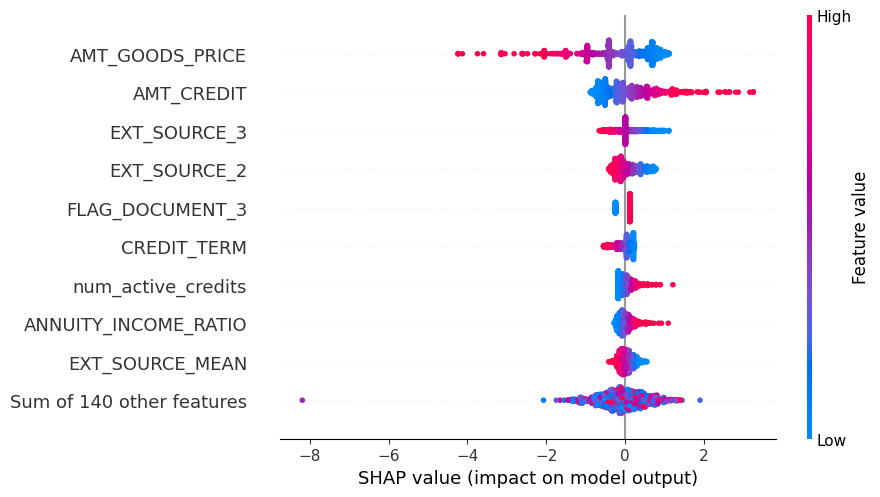

In [10]:
# the beeswarm function expects a 2D array, not 3D - pick the positive class
shap.plots.beeswarm(shap_values)

We know that a feature whose dots are spread out more evenly along the x-axis has higher importance. Based on this knowledge, we see that the following features have high importance, among others:
- External source credit score data: Logical, as other lenders' own scores can give us some insight into the tendencies of applicants
- `CREDIT_TERM`: A long credit term can indicate that the applicant may not have the needs to quickly pay off a loan and will eventually default
- `num_active_credits`: The number of active loans an applicant has can be a sign of financial instability and constantly needing to take out loans

### Bar plot of mean |SHAP|

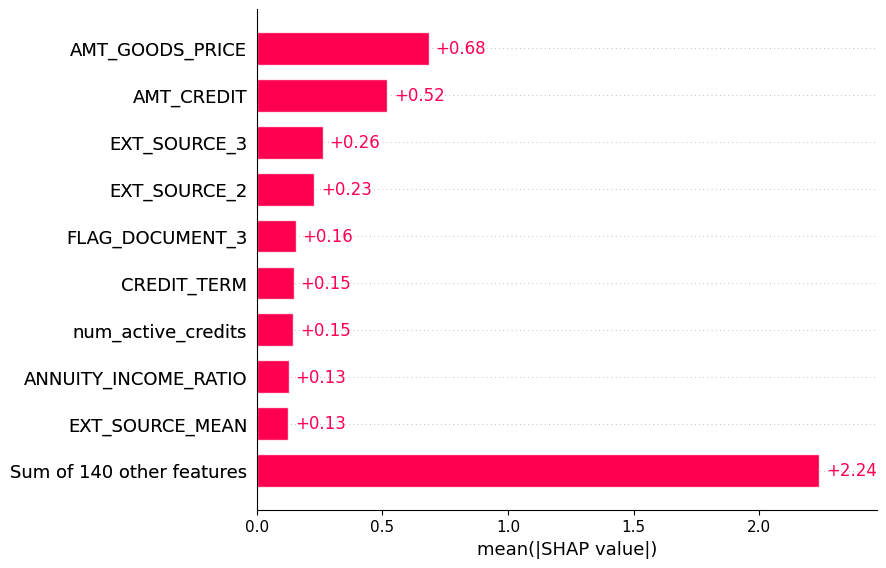

In [11]:
shap.plots.bar(shap_values)

## Select 3 individual applicants: one high-risk (predicted PD > 0.5), one borderline (PD 0.2–0.4), one low-risk (PD < 0.1). Generate SHAP waterfall plots for each.

We need to pick three applicants, one with predicted probability > 0.5 (most likely to default), one medium risk (predicted probability 0.2-0.4), and one low risk (predicted probability < 0.1)

In [12]:
y_sample_proba = best_model.predict_proba(X_test)[:, 1]
# get positive class probabilities

# copy testing dataframe into new dataframe, and add probabilities
applicant_probabilities = X_test.copy()
applicant_probabilities['Default Probability'] = y_sample_proba
applicant_probabilities['Actual Result'] = y_test
display(applicant_probabilities)

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,"AGE_BUCKET_(20, 30]","AGE_BUCKET_(30, 40]","AGE_BUCKET_(40, 50]","AGE_BUCKET_(50, 60]","AGE_BUCKET_(60, 70]","AGE_BUCKET_(70, 100]",Default Probability,Actual Result
256571,1,157500.0,770292.0,30676.5,688500.0,4,0.010147,-13506,-105.0,-2876.0,...,0,0,0,1,0,0,0,0,0.437052,0
191493,0,90000.0,364896.0,19926.0,315000.0,2,0.007330,-17723,-4930.0,-4654.0,...,0,0,0,0,1,0,0,0,0.386979,0
103497,0,148500.0,284400.0,18643.5,225000.0,2,0.014464,-24200,-1191.0,-12511.0,...,0,0,0,0,0,0,1,0,0.741516,0
130646,0,188100.0,976711.5,38218.5,873000.0,4,0.020713,-9650,-355.0,-969.0,...,0,0,1,0,0,0,0,0,0.483122,0
211898,0,180000.0,323194.5,19660.5,279000.0,2,0.035792,-17487,-1366.0,-10063.0,...,0,0,0,0,1,0,0,0,0.613823,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16213,0,162000.0,834048.0,27693.0,720000.0,2,0.022625,-20906,-1648.0,-7631.0,...,0,1,0,0,0,1,0,0,0.429436,0
294620,0,180000.0,1305000.0,38155.5,1305000.0,4,0.018850,-17790,-1188.0,-10377.0,...,0,0,0,0,1,0,0,0,0.407970,0
234384,1,360000.0,239850.0,27058.5,225000.0,4,0.010276,-13369,-1194.0,-7353.0,...,0,0,0,1,0,0,0,0,0.339003,0
149027,0,337500.0,900000.0,45954.0,900000.0,3,0.009630,-11364,-1086.0,-1312.0,...,0,0,0,1,0,0,0,0,0.667749,1


In [13]:
# create some filters
low_probability_filter = applicant_probabilities['Default Probability'] < 0.1
borderline_probability_filter = (applicant_probabilities['Default Probability'] > 0.2) & (applicant_probabilities['Default Probability'] < 0.4)
high_probability_filter = applicant_probabilities['Default Probability'] > 0.5

low_probability_applicants = applicant_probabilities[low_probability_filter]
borderline_probability_applicants = applicant_probabilities[borderline_probability_filter]
high_probability_applicants = applicant_probabilities[high_probability_filter]

display(low_probability_applicants)
display(borderline_probability_applicants)
display(high_probability_applicants)

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,"AGE_BUCKET_(20, 30]","AGE_BUCKET_(30, 40]","AGE_BUCKET_(40, 50]","AGE_BUCKET_(50, 60]","AGE_BUCKET_(60, 70]","AGE_BUCKET_(70, 100]",Default Probability,Actual Result
287975,0,319500.0,1431000.0,39483.0,1431000.0,4,0.002042,-14050,-5733.0,-4031.0,...,1,0,0,1,0,0,0,0,0.073147,0
144906,0,157500.0,382500.0,19125.0,382500.0,2,0.030755,-21827,-1648.0,-9707.0,...,0,0,0,0,0,1,0,0,0.084290,0
276723,0,135000.0,1647000.0,43578.0,1647000.0,2,0.022800,-20853,-1648.0,-9582.0,...,0,1,0,0,0,1,0,0,0.049974,0
146834,1,270000.0,450000.0,22500.0,720000.0,4,0.009175,-17471,-605.0,-1798.0,...,0,0,0,0,1,0,0,0,0.078892,0
639,1,315000.0,1971072.0,62019.0,1800000.0,4,0.032561,-16938,-1744.0,-3240.0,...,0,0,0,0,1,0,0,0,0.096119,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4284,0,202500.0,1732500.0,45832.5,1732500.0,4,0.026392,-19095,-4847.0,-1236.0,...,1,0,0,0,0,1,0,0,0.068461,0
112680,0,135000.0,270000.0,13500.0,270000.0,4,0.030755,-15408,-6109.0,-4798.0,...,1,0,0,0,1,0,0,0,0.087720,0
175213,1,247500.0,2695500.0,71235.0,2250000.0,2,0.011657,-14794,-7977.0,-8193.0,...,0,0,0,0,1,0,0,0,0.074431,0
232919,0,180000.0,1170000.0,47781.0,1170000.0,4,0.046220,-10295,-1618.0,-4195.0,...,0,0,1,0,0,0,0,0,0.078380,0


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,"AGE_BUCKET_(20, 30]","AGE_BUCKET_(30, 40]","AGE_BUCKET_(40, 50]","AGE_BUCKET_(50, 60]","AGE_BUCKET_(60, 70]","AGE_BUCKET_(70, 100]",Default Probability,Actual Result
191493,0,90000.0,364896.0,19926.0,315000.0,2,0.007330,-17723,-4930.0,-4654.0,...,0,0,0,0,1,0,0,0,0.386979,0
254495,0,202500.0,225000.0,11250.0,225000.0,2,0.008474,-19578,-1648.0,-3380.0,...,0,0,0,0,0,1,0,0,0.399700,1
279469,0,90000.0,269550.0,24853.5,225000.0,4,0.035792,-10687,-790.0,-5206.0,...,0,0,1,0,0,0,0,0,0.207564,0
245557,1,117000.0,691020.0,26905.5,495000.0,4,0.018029,-11509,-742.0,-1320.0,...,0,0,0,1,0,0,0,0,0.357050,0
277669,0,210600.0,619965.0,20128.5,517500.0,2,0.003813,-20555,-1648.0,-4364.0,...,0,0,0,0,0,1,0,0,0.237605,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133923,1,225000.0,719860.5,48429.0,679500.0,2,0.007274,-12311,-2247.0,-6230.0,...,1,0,0,1,0,0,0,0,0.273568,0
104934,0,135000.0,500211.0,32125.5,463500.0,3,0.024610,-10972,-2853.0,-1481.0,...,0,0,0,1,0,0,0,0,0.307320,0
137914,0,441000.0,1288350.0,37800.0,1125000.0,2,0.002506,-9614,-1526.0,-1460.0,...,0,0,1,0,0,0,0,0,0.252235,0
208523,0,112500.0,808650.0,26217.0,675000.0,2,0.005144,-20022,-4304.0,-9537.0,...,0,0,0,0,0,1,0,0,0.306854,0


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,"AGE_BUCKET_(20, 30]","AGE_BUCKET_(30, 40]","AGE_BUCKET_(40, 50]","AGE_BUCKET_(50, 60]","AGE_BUCKET_(60, 70]","AGE_BUCKET_(70, 100]",Default Probability,Actual Result
103497,0,148500.0,284400.0,18643.5,225000.0,2,0.014464,-24200,-1191.0,-12511.0,...,0,0,0,0,0,0,1,0,0.741516,0
211898,0,180000.0,323194.5,19660.5,279000.0,2,0.035792,-17487,-1366.0,-10063.0,...,0,0,0,0,1,0,0,0,0.613823,0
130549,1,90000.0,318528.0,8532.0,252000.0,2,0.031329,-11471,-451.0,-6069.0,...,0,0,0,1,0,0,0,0,0.672438,0
102173,0,112500.0,170640.0,13612.5,135000.0,2,0.025164,-15710,-683.0,-2276.0,...,0,0,0,0,1,0,0,0,0.821962,0
128470,0,66150.0,158256.0,12424.5,144000.0,2,0.018029,-24413,-1648.0,-12557.0,...,1,0,0,0,0,0,1,0,0.529624,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187237,0,112500.0,157500.0,7875.0,157500.0,2,0.015221,-9894,-644.0,-680.0,...,0,0,1,0,0,0,0,0,0.624864,0
234844,0,180000.0,674635.5,28714.5,603000.0,2,0.018850,-20378,-1648.0,-6839.0,...,0,0,0,0,0,1,0,0,0.717733,1
85131,0,180000.0,225000.0,24232.5,225000.0,2,0.030755,-12615,-2079.0,-2546.0,...,0,1,0,1,0,0,0,0,0.578586,0
149027,0,337500.0,900000.0,45954.0,900000.0,3,0.009630,-11364,-1086.0,-1312.0,...,0,0,0,1,0,0,0,0,0.667749,1


For simplicity reasons, we'll take the first applicant from each subset

In [14]:
low_probability_subject = low_probability_applicants.iloc[[0]]
borderline_probability_subject = borderline_probability_applicants.iloc[[0]]
high_probability_subject = high_probability_applicants.iloc[[0]]

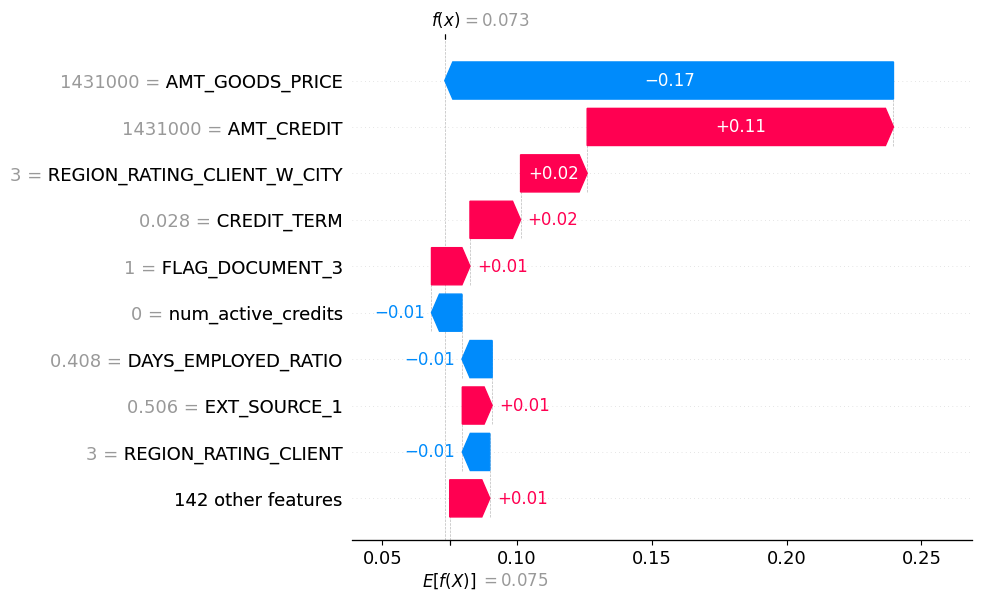

In [15]:
explainer_low = shap.Explainer(best_model.predict_proba, low_probability_applicants)
low_risk_shap = explainer_low(low_probability_subject)
shap.plots.waterfall(low_risk_shap[:, :, 1][0])

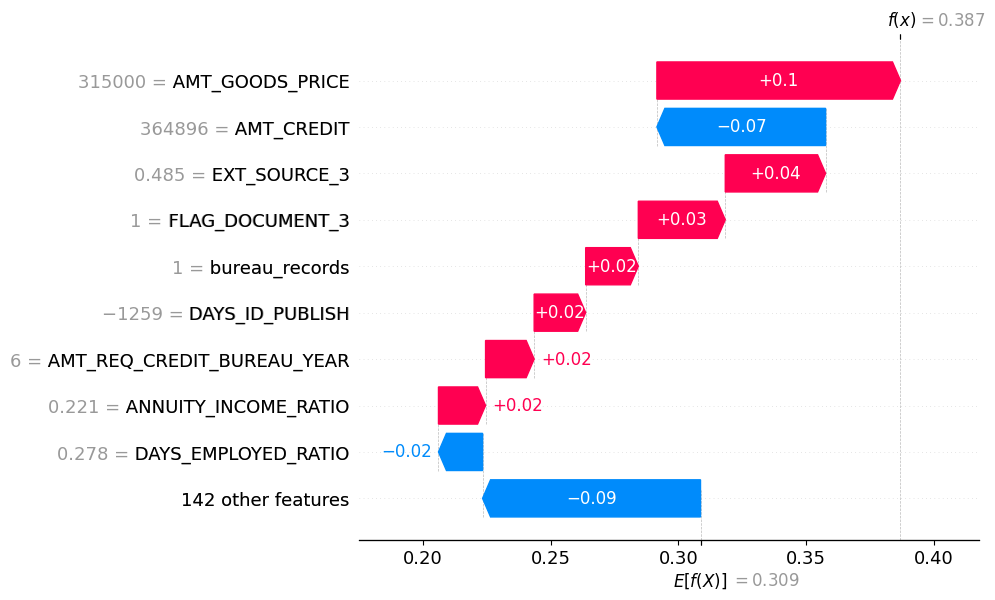

In [16]:
explainer_borderline = shap.Explainer(best_model.predict_proba, borderline_probability_applicants)
borderline_risk_shap = explainer_borderline(borderline_probability_subject)
shap.plots.waterfall(borderline_risk_shap[:, :, 1][0])

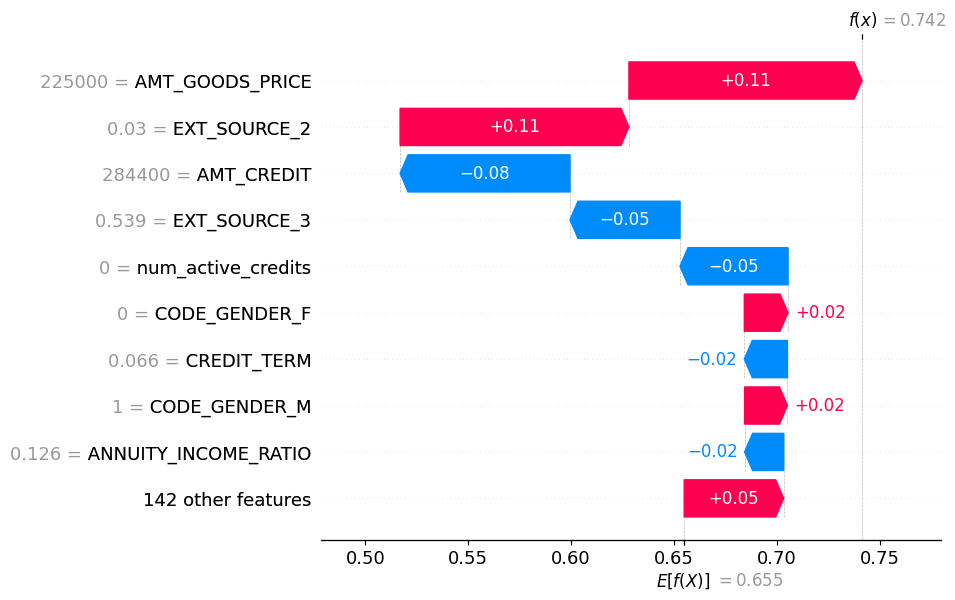

In [17]:
explainer_high = Explainer(best_model.predict_proba, high_probability_applicants)
high_probability_shap = explainer_high(high_probability_subject)
shap.plots.waterfall(high_probability_shap[:, :, 1][0])

After having generated the SHAP waterfall plots for the tree individual applicants, we now look at how to interpet said plots
- The vertical expected value line $E[f(x)]$ is the baseline value, then we see how each feature either positively/negatively contributes to the final overall probability of whether an applicant will default
- Positive push is indicated by a red arrow to the right, negative push is indicated by a blue arrow to the left

## Adverse action notice - high risk applicant

According to the Equal Credit Opportunity Act (ECOA), specific reasoning must be provided when denying credit. Based on the waterfall plot, we can make the following conclusions (as per ECOA we are not permitted to use features relating to matters such as gender to make decisions about whether to approval/reject the loan):
- EXT_SOURCE_2: Credit score of 0.03 is below the specified threshold of 0.4 (for example)
- AMT_GOODS_PRICE: Value of item(s) for which loan is for is too high (225000), exceeds specified threshold of 175000 (for example)

## Compute Population Stability Index (PSI) between training and test distributions for the top 10 features. Flag any with PSI > 0.25 (indicating distribution shift)

First compute top 10 features

In [18]:
# create Series/DataFrame with feature importances
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.DataFrame(
    {"feature": X.columns, "importance": mean_abs_shap}
)

feature_importances = feature_importance.sort_values(
    by="importance", ascending=False
).reset_index(drop=True)

display(feature_importances)

,feature,importance
0,AMT_GOODS_PRICE,6.849064e-01
1,AMT_CREDIT,5.192498e-01
2,EXT_SOURCE_3,2.626871e-01
3,EXT_SOURCE_2,2.293821e-01
4,FLAG_DOCUMENT_3,1.560905e-01
...,...,...
144,FLAG_MOBIL,3.324988e-20
145,FLAG_DOCUMENT_21,2.688163e-20
146,NAME_INCOME_TYPE_Maternity leave,2.674924e-20
147,FLAG_DOCUMENT_7,1.035195e-20


In [19]:
top_10_features = feature_importances.sort_values(by=['importance'], ascending=False).head(10)['feature']
top_10_features

0         AMT_GOODS_PRICE
1              AMT_CREDIT
2            EXT_SOURCE_3
3            EXT_SOURCE_2
4         FLAG_DOCUMENT_3
5             CREDIT_TERM
6      num_active_credits
7    ANNUITY_INCOME_RATIO
8         EXT_SOURCE_MEAN
9             AMT_ANNUITY
Name: feature, dtype: object

Next up, we define PSI as `sum((actual_pct - expected_pct) * ln(actual_pct / expected_pct))`

In [20]:
def compute_PSI(training_data, testing_data, bins=10):
#     split data into bins

    breakpoints = np.unique(np.quantile(training_data, np.linspace(0, 1, bins + 1)))
    
    # get the counts/distribution per biin for training and test data
    expected_counts = pd.cut(training_data, bins=breakpoints, include_lowest=True).value_counts(sort=False)
    actual_counts = pd.cut(testing_data, bins=breakpoints, include_lowest=True).value_counts(sort=False)
    expected_pct = expected_counts / expected_counts.sum()
    actual_pct = actual_counts / actual_counts.sum()
    psi = ((actual_pct - expected_pct) *
           np.log(actual_pct / expected_pct)).sum()

    return psi

In [21]:
psi_results = {}
for feature in top_10_features:
    psi_results[feature] = compute_PSI(X_train[feature], X_test[feature], bins=10)

psi_results

{'AMT_GOODS_PRICE': 0.0001232968722419488,
 'AMT_CREDIT': 0.00010935568913455672,
 'EXT_SOURCE_3': 0.00018653120182146344,
 'EXT_SOURCE_2': 0.00012281937317160771,
 'FLAG_DOCUMENT_3': 0.0,
 'CREDIT_TERM': 0.00021494886656570625,
 'num_active_credits': 0.00010700875461739455,
 'ANNUITY_INCOME_RATIO': 0.0001256948594830818,
 'EXT_SOURCE_MEAN': 0.00030642457598845574,
 'AMT_ANNUITY': 0.00024693963450111674}

The low PSI values can be explained through the following reasons:
- The samples are all pulled from one dataset, there is no time series data to indicate a clear before/after dataset
- The dataset contains some 300k+ rows. According to the Central Limit Theorem, the distribution of the sample means will follow an approximate normal distribution. This means that the train and test subsets, which were derived from the original dataset, will also both follow roughly a normal distribution, and this goes for all features

## Create a model monitoring dashboard: a summary figure showing (a) AUROC by validation fold, (b) top 10 feature importances, (c) PSI heatmap.

In [22]:
feature_importances_sorted = feature_importances.sort_values(by=['importance'], ascending=False).head(10)
features = feature_importances_sorted.index
feature_scores = feature_importances_sorted['importance']

display(feature_importances_sorted)
display(features)
display(feature_scores)

,feature,importance
0,AMT_GOODS_PRICE,0.684906
1,AMT_CREDIT,0.519250
2,EXT_SOURCE_3,0.262687
3,EXT_SOURCE_2,0.229382
4,FLAG_DOCUMENT_3,0.156090
5,CREDIT_TERM,0.146439
6,num_active_credits,0.145244
7,ANNUITY_INCOME_RATIO,0.126573
8,EXT_SOURCE_MEAN,0.125062
9,AMT_ANNUITY,0.119558


Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype='int64')

0    0.684906
1    0.519250
2    0.262687
3    0.229382
4    0.156090
5    0.146439
6    0.145244
7    0.126573
8    0.125062
9    0.119558
Name: importance, dtype: float64

In [23]:
psi_df = pd.DataFrame(pd.Series(data=psi_results, index=psi_results.keys())).rename(columns={0: 'PSI'})
psi_df

,PSI
AMT_GOODS_PRICE,0.000123
AMT_CREDIT,0.000109
EXT_SOURCE_3,0.000187
EXT_SOURCE_2,0.000123
FLAG_DOCUMENT_3,0.000000
CREDIT_TERM,0.000215
num_active_credits,0.000107
ANNUITY_INCOME_RATIO,0.000126
EXT_SOURCE_MEAN,0.000306
AMT_ANNUITY,0.000247


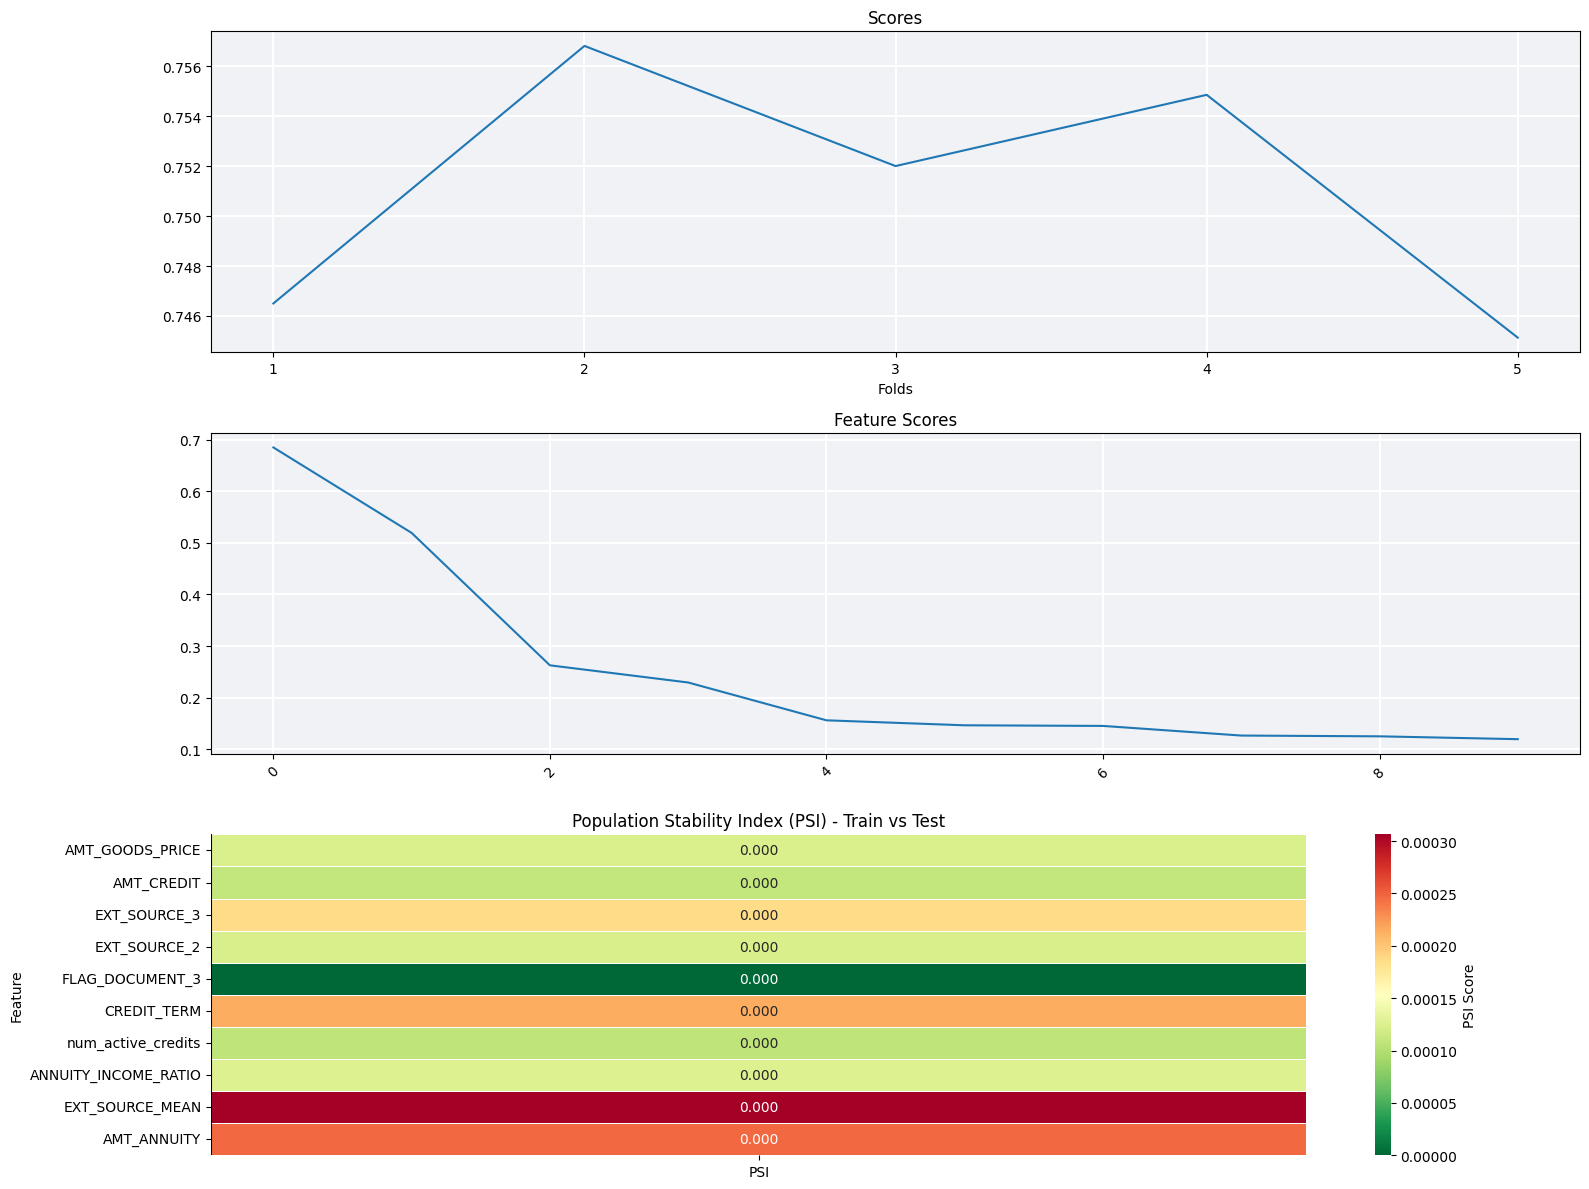

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# give all plots equal space (make them all centred)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 12), gridspec_kw={"height_ratios": [1, 1, 1]})

axes[0].plot(range(1, 6), scores)
axes[0].set_title("Scores")
axes[0].set_xlabel("Folds")
axes[0].set_xticks(range(1, 6))

axes[0].grid(
    visible=True,       
    which='major',     
    axis='both',       
    color='white',      
    linestyle='-',     
    linewidth=1.5,      
    alpha=1.0           
)
axes[0].set_facecolor("#f0f2f6")

axes[1].plot(features, feature_scores)
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_title("Feature Scores")

axes[1].grid(
    visible=True,       
    which='major',     
    axis='both',       
    color='white',      
    linestyle='-',     
    linewidth=1.5,      
    alpha=1.0           
)
axes[1].set_facecolor("#f0f2f6")

sns.heatmap(
    psi_df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    vmin=0,
    linewidths=0.5,
    cbar_kws={"label": "PSI Score"},
    ax=axes[2]
)

axes[2].axvline(0, color="black")
axes[2].set_title("Population Stability Index (PSI) - Train vs Test")
axes[2].set_ylabel("Feature")

plt.tight_layout()
plt.show()